In [37]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import json
from tensorflow.keras.preprocessing import image

In [38]:
@tf.keras.utils.register_keras_serializable()
def preprocess_input(x):
    return tf.keras.applications.mobilenet_v2.preprocess_input(x)

# load class names
with open('../json/cat_and_dog.json', 'r') as f:
    class_names = json.load(f)

# load model
model = tf.keras.models.load_model('../models/cat_vs_dogv1.keras')

print("Model loaded successfully!",model)

Model loaded successfully! <Sequential name=sequential_5, built=True>


In [39]:
# # Path to the image (images.jpeg yang ada di root directory)
# img_path = '../images/anjing.jpeg'

# # Ukuran gambar yang digunakan saat training
# IMAGE_SIZE = 160

# # Load dan preprocessing gambar
# img = image.load_img(img_path, target_size=(IMAGE_SIZE, IMAGE_SIZE))
# img_array = image.img_to_array(img)
# img_array = np.expand_dims(img_array, axis=0) # Tambahkan dimensi batch
# # img_array = img_array / 255.0 # Normalisasi gambar (sesuai tahap training)
# img_array = tf.keras.applications.mobilenet_v2.preprocess_input(img_array)
# # Lakukan prediksi
# predictions = model.predict(img_array)

# # Tampilkan hasil prediksi dari multiple output
# print('============== Hasil Prediksi ==============')
# for i, class_name in enumerate(class_names):
#     # Multi-label probability: kalikan dengan 100 untuk persentase
#     persentase = predictions[0][i] * 100
#     print(f'{class_name}: {persentase:.2f}%')
# print('============================================')

# # Tampilkan gambar
# plt.imshow(img)
# plt.title('Gambar Asli')
# plt.axis('off')
# plt.show()

In [40]:
from tensorflow.keras.preprocessing import image
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# Path gambar
img_path = '../images/kucing.jpeg'

# ukuran image
IMAGE_SIZE = 160

# load image
img = image.load_img(
    img_path,
    target_size=(IMAGE_SIZE, IMAGE_SIZE)
)

# convert ke array
img_array = image.img_to_array(img)

# tambah batch dimension
img_array = np.expand_dims(img_array, axis=0)

# PREPROCESS SESUAI MOBILENETV2
img_array = tf.keras.applications.mobilenet_v2.preprocess_input(img_array)

# # prediksi
# predictions = model.predict(img_array)

# print("============== Hasil Prediksi ==============")

# print(predictions)

# print("============================================")

# # tampilkan gambar
# plt.imshow(img)
# plt.title("Gambar Asli")
# plt.axis("off")
# plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 225ms/step
============== HASIL PREDIKSI ==============
Dog : 50.00%
Cat : 50.00%


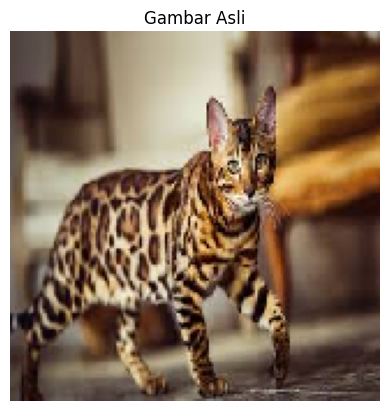

In [41]:
# predict
prediction = model.predict(img_array)[0][0]

print("============== HASIL PREDIKSI ==============")

if prediction > 0.5:

    dog_prob = prediction * 100

    print(f"Dog : {dog_prob:.2f}%")
    print(f"Cat : {100 - dog_prob:.2f}%")

else:

    cat_prob = (1 - prediction) * 100

    print(f"Cat : {cat_prob:.2f}%")
    print(f"Dog : {100 - cat_prob:.2f}%")

print("============================================")

# tampilkan image
plt.imshow(img)
plt.title("Gambar Asli")
plt.axis("off")
plt.show()